# k-최근접 이웃 예측의 한계가 있다
# 그래서 ```선형 회귀```를 사용한다

In [1]:
import numpy as np

perch_length = np.array(
    [8.4, 13.7, 15.0, 16.2, 17.4, 18.0, 18.7, 19.0, 19.6, 20.0,
     21.0, 21.0, 21.0, 21.3, 22.0, 22.0, 22.0, 22.0, 22.0, 22.5,
     22.5, 22.7, 23.0, 23.5, 24.0, 24.0, 24.6, 25.0, 25.6, 26.5,
     27.3, 27.5, 27.5, 27.5, 28.0, 28.7, 30.0, 32.8, 34.5, 35.0,
     36.5, 36.0, 37.0, 37.0, 39.0, 39.0, 39.0, 40.0, 40.0, 40.0,
     40.0, 42.0, 43.0, 43.0, 43.5, 44.0]
     )
perch_weight = np.array(
    [5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0,
     110.0, 115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0,
     130.0, 150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0,
     197.0, 218.0, 300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0,
     514.0, 556.0, 840.0, 685.0, 700.0, 700.0, 690.0, 900.0, 650.0,
     820.0, 850.0, 900.0, 1015.0, 820.0, 1100.0, 1000.0, 1100.0,
     1000.0, 1000.0]
     )

In [2]:
from sklearn.model_selection import train_test_split

train_input, test_input, train_target, test_target = \
    train_test_split(perch_length, perch_weight, random_state=42)

train_input = train_input.reshape(-1, 1)
test_input = test_input.reshape(-1, 1)

print(train_input.shape, test_input.shape)

(42, 1) (14, 1)


In [3]:
## k-최근접 이웃 예측 방법으로 훈련한다
from sklearn.neighbors import KNeighborsRegressor

knr = KNeighborsRegressor(n_neighbors=3)

knr.fit(train_input, train_target)

KNeighborsRegressor(algorithm='auto', leaf_size=30, metric='minkowski',
                    metric_params=None, n_jobs=None, n_neighbors=3, p=2,
                    weights='uniform')

In [5]:
# 길이를 50을 줬을 때, 무게는?
print(knr.predict([[50]]))

[1033.33333333]


###  length=50 일 때, weight를 1033.333333으로 예측했다

- 데이터의 관찰을 위해 시각화를 해보자

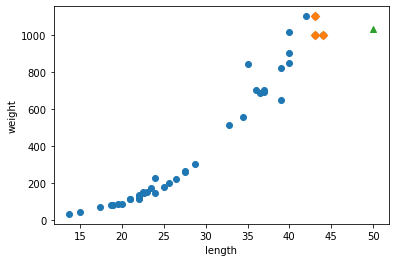

In [6]:
import matplotlib.pyplot as plt

distances, indexes = knr.kneighbors([[50]])

plt.scatter(train_input, train_target)
plt.scatter(train_input[indexes], train_target[indexes], marker='D')

plt.scatter(50, 1033, marker='^')
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

In [7]:
# 가장 가까운 3개의 평균 weight계산
print(np.mean(train_target[indexes]))

1033.3333333333333


In [8]:
# 이번에는 length=100일 때, weight는?
print(knr.predict([[100]]))

[1033.33333333]


In [9]:
# 이번에는 length=1000일 때, weight는?
print(knr.predict([[1000]]))

[1033.33333333]


## 위의 결과를 토대로 k-최근접 이웃 예측 방법은 적절치 않다
## 그래서 선형 회귀로 바꾼다

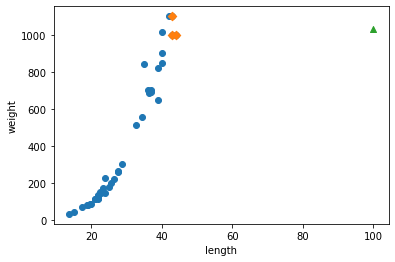

In [10]:
# 훈련 데이터와 길이가 100인 데이터를 시각화

distances, indexes = knr.kneighbors([[100]])

plt.scatter(train_input, train_target)

plt.scatter(train_input[indexes], train_target[indexes], marker='D')

plt.scatter(100, 1033, marker='^')
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

## 선형 회귀(linear regression)
- 어떤 직선이 데이터들의 분포를 가장 잘 나타내는가
- 해당 직선을 찾자

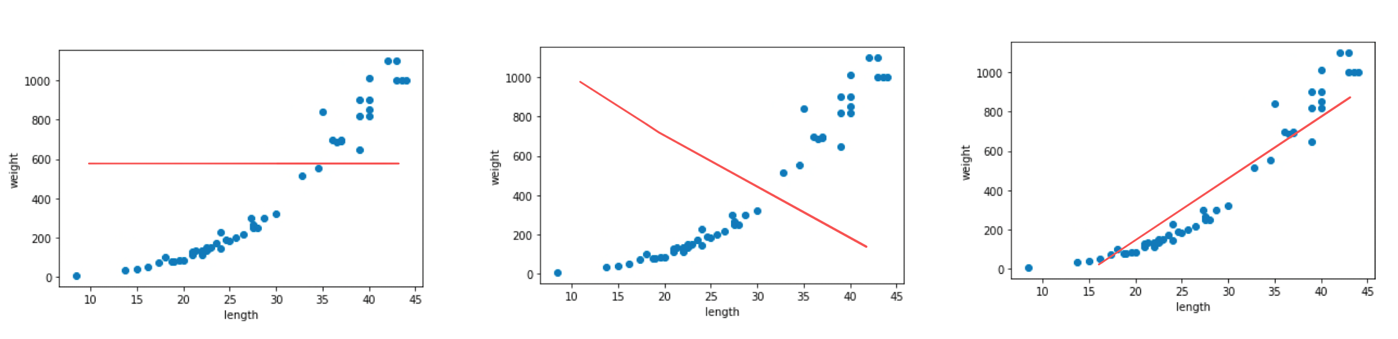

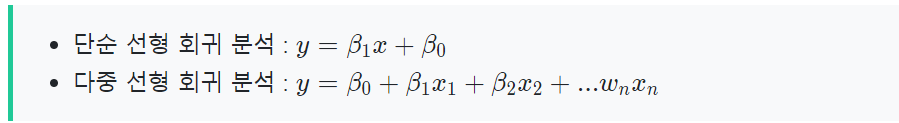

In [11]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(train_input, train_target)

print(lr.predict([[50]]))

[1241.83860323]


In [12]:
# y = ax + b
# a = lr.coef_      : weight(가중치), coefficient(계수), 기울기
# b = lr.intercept_ : bias(편향), 절편
# 결국 fit 훈련을 통해서 가장 데이터의 특성 잘 나타내는 a, b를 찾는 것이다
print(lr.coef_, lr.intercept_)

[39.01714496] -709.0186449535474


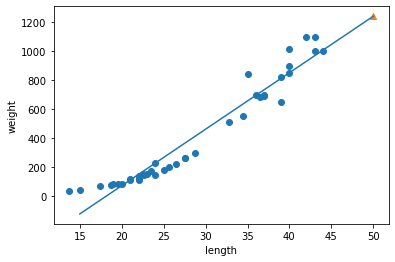

In [13]:
# 시각화를 해보자
plt.scatter(train_input, train_target)

# 농어의 길이 15 ~ 50까지 직선으로 그린 것
plt.plot([15, 50], [15*lr.coef_ + lr.intercept_, 50*lr.coef_ + lr.intercept_])

plt.scatter(50, 1241.8, marker='^')
plt.xlabel('length')
plt.ylabel('weight')
plt.show()